# 06 Manuell Variabeltesting



In [32]:
### Unngå time-outing ved oppstart
print("hello world")

hello world


In [33]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_poisson_deviance

sns.set_theme(style="whitegrid")

project_root = Path.cwd().resolve().parent.parent
code_dir = project_root / "code"
if str(code_dir) not in sys.path:
    sys.path.append(str(code_dir))

from utils.data_load import load_raw_data
from utils.data_prep import data_prep
from utils.models import (
    fit_count_model,
    fit_mean_duration_model,
    build_count_model,
    build_mean_duration_model,
    cross_validate_count_model,
    cross_validate_mean_duration_model,
    DEFAULT_CATEGORICAL_FEATURES,
)

In [34]:
# Konfig
COUNT_TARGET = "antall_samtaler"
DURATION_TARGET = "behandlingstid_snitt"
TOTAL_TARGET = "total_behandlingstid"
WEIGHT_COL = "antall_samtaler"

K_FOLDS = 10
RANDOM_STATE = 42
POISSON_ALPHA = 0.3
POISSON_MAX_ITER = 10000

NEWSLETTER_CSV = project_root / "data" / "newsletter_sendouts.csv"
WEATHER_CSV = project_root / "data" / "oslo_weather.csv"

# Manuell start fra CV-resultater i 03 (antall samtaler)
count_feature_cols = [
    "maaned",
    "stddev_premieendring_b30_for",
    "antall_hf_f30_tot",
    "stddev_premieendring_f30_for",
    "snitt_premieendring_f30_for",
    "snitt_premieendring_b30_for",
    "er_dag_foer_helligdag",
    "ukedag",
]

# Manuell start fra CV-resultater i 04 (snitt behandlingstid)
duration_feature_cols = [
    "antall_nye_kunder_b30_tot",
    "maaned",
    "stddev_premieendring_b30_for",
    "snitt_premieendring_b30_for",
    "snitt_premieendring_f30_for",
]

# Endelig modell bruker unionen av de to listene
product_feature_cols = sorted(set(count_feature_cols) | set(duration_feature_cols))

print("Count features:", count_feature_cols)
print("Duration features:", duration_feature_cols)
print("Product features (union):", product_feature_cols)

Count features: ['maaned', 'stddev_premieendring_b30_for', 'antall_hf_f30_tot', 'stddev_premieendring_f30_for', 'snitt_premieendring_f30_for', 'snitt_premieendring_b30_for', 'er_dag_foer_helligdag', 'ukedag']
Duration features: ['antall_nye_kunder_b30_tot', 'maaned', 'stddev_premieendring_b30_for', 'snitt_premieendring_b30_for', 'snitt_premieendring_f30_for']
Product features (union): ['antall_hf_f30_tot', 'antall_nye_kunder_b30_tot', 'er_dag_foer_helligdag', 'maaned', 'snitt_premieendring_b30_for', 'snitt_premieendring_f30_for', 'stddev_premieendring_b30_for', 'stddev_premieendring_f30_for', 'ukedag']


In [35]:
# Last data og bygg analyseklar dataframe
df_inngang, df_info, df_weather = load_raw_data(
    session=None,
    weather_path=WEATHER_CSV,
)

df = data_prep(
    df_inngang=df_inngang,
    df_info=df_info,
    df_weather=df_weather,
    cols_to_remove=None,
    newsletter_dates_csv=str(NEWSLETTER_CSV),
)

print("Prepared shape:", df.shape)
print("Dato fra/til:", df["ankomst_dato"].min(), "->", df["ankomst_dato"].max())

Prepared shape: (499, 140)
Dato fra/til: 2024-06-03 -> 2026-06-02


In [36]:
# Hjelpefunksjoner

def metric_row(y_true, y_pred, sample_weight=None):
    return {
        "mae": mean_absolute_error(y_true, y_pred, sample_weight=sample_weight),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred, sample_weight=sample_weight))),
        "r2": r2_score(y_true, y_pred, sample_weight=sample_weight),
    }


def plot_diagnostics(df_plot, y_col, pred_col, date_col, title):
    y_true = df_plot[y_col]
    y_pred = df_plot[pred_col]
    resid = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(x=y_true, y=y_pred, s=28, alpha=0.7, ax=axes[0])
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    axes[0].plot([lo, hi], [lo, hi], "r--")
    axes[0].set_title(f"{title}: faktisk vs predikert")
    axes[0].set_xlabel(y_col)
    axes[0].set_ylabel(pred_col)

    sns.scatterplot(x=y_pred, y=resid, s=28, alpha=0.7, ax=axes[1])
    axes[1].axhline(0, color="red", linestyle="--")
    axes[1].set_title(f"{title}: residual vs predikert")
    axes[1].set_xlabel(pred_col)
    axes[1].set_ylabel("residual")

    df_ts = df_plot.sort_values(date_col)
    axes[2].plot(df_ts[date_col], df_ts[y_col], label="faktisk", linewidth=1.8)
    axes[2].plot(df_ts[date_col], df_ts[pred_col], label="predikert", linewidth=1.5)
    axes[2].set_title(f"{title}: tidsserie")
    axes[2].tick_params(axis="x", rotation=30)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def _ordered_levels(series, col, max_levels=10):
    series = series.dropna()
    if series.empty:
        return []

    # Maaned skal alltid leses kronologisk (1-12).
    if col == "maaned":
        numeric = pd.to_numeric(series, errors="coerce").dropna().astype(int)
        present = set(numeric.tolist())
        return [m for m in range(1, 13) if m in present]

    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().all():
        vals = sorted(pd.Series(numeric).dropna().unique().tolist())
        return vals[:max_levels]

    vals = series.drop_duplicates().tolist()
    vals = sorted(vals, key=lambda v: str(v))
    return vals[:max_levels]


def plot_marginal_effects(model, X_ref, feature_cols, categorical_cols, title, max_vars=6):
    vars_to_plot = feature_cols[:max_vars]
    if not vars_to_plot:
        return

    n = len(vars_to_plot)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(vars_to_plot):
        ax = axes[i]
        is_cat = col in categorical_cols

        if is_cat:
            series = X_ref[col].dropna()
            if series.empty:
                ax.set_visible(False)
                continue

            levels = _ordered_levels(series, col, max_levels=10)
            rows = []
            for level in levels:
                x_tmp = X_ref.copy()
                x_tmp[col] = level
                rows.append({"level": str(level), "pred_mean": float(model.predict(x_tmp).mean())})
            plot_df = pd.DataFrame(rows)
            sns.barplot(data=plot_df, x="level", y="pred_mean", ax=ax, color="#4C72B0", order=[str(l) for l in levels])
            ax.tick_params(axis="x", rotation=30)
            ax.set_xlabel(col)
            ax.set_ylabel("gjennomsnittlig prediksjon")
            ax.set_title(f"Marginal: {col}")
        else:
            series = pd.to_numeric(X_ref[col], errors="coerce").dropna()
            if series.empty:
                ax.set_visible(False)
                continue
            x_grid = np.linspace(series.quantile(0.05), series.quantile(0.95), 40)
            rows = []
            for x_val in x_grid:
                x_tmp = X_ref.copy()
                x_tmp[col] = x_val
                rows.append({col: x_val, "pred_mean": float(model.predict(x_tmp).mean())})
            plot_df = pd.DataFrame(rows)
            sns.lineplot(data=plot_df, x=col, y="pred_mean", ax=ax)
            ax.set_xlabel(col)
            ax.set_ylabel("gjennomsnittlig prediksjon")
            ax.set_title(f"Marginal: {col}")

    for j in range(len(vars_to_plot), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_product_marginals(count_model, duration_model, X_ref, feature_cols, categorical_cols, title, max_vars=6):
    vars_to_plot = feature_cols[:max_vars]
    if not vars_to_plot:
        return

    n = len(vars_to_plot)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(vars_to_plot):
        ax = axes[i]
        is_cat = col in categorical_cols

        if is_cat:
            series = X_ref[col].dropna()
            if series.empty:
                ax.set_visible(False)
                continue

            levels = _ordered_levels(series, col, max_levels=10)
            rows = []
            for level in levels:
                x_tmp = X_ref.copy()
                x_tmp[col] = level
                pred = np.clip(count_model.predict(x_tmp), 1e-9, None) * np.clip(duration_model.predict(x_tmp), 1e-9, None)
                rows.append({"level": str(level), "pred_mean": float(np.mean(pred))})
            plot_df = pd.DataFrame(rows)
            sns.barplot(data=plot_df, x="level", y="pred_mean", ax=ax, color="#55A868", order=[str(l) for l in levels])
            ax.tick_params(axis="x", rotation=30)
            ax.set_xlabel(col)
            ax.set_ylabel("gjennomsnittlig predikert total")
            ax.set_title(f"Marginal: {col}")
        else:
            series = pd.to_numeric(X_ref[col], errors="coerce").dropna()
            if series.empty:
                ax.set_visible(False)
                continue
            x_grid = np.linspace(series.quantile(0.05), series.quantile(0.95), 40)
            rows = []
            for x_val in x_grid:
                x_tmp = X_ref.copy()
                x_tmp[col] = x_val
                pred = np.clip(count_model.predict(x_tmp), 1e-9, None) * np.clip(duration_model.predict(x_tmp), 1e-9, None)
                rows.append({col: x_val, "pred_mean": float(np.mean(pred))})
            plot_df = pd.DataFrame(rows)
            sns.lineplot(data=plot_df, x=col, y="pred_mean", ax=ax)
            ax.set_xlabel(col)
            ax.set_ylabel("gjennomsnittlig predikert total")
            ax.set_title(f"Marginal: {col}")

    for j in range(len(vars_to_plot), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

In [37]:
# Valider feature-lister mot tilgjengelige kolonner
count_missing = [c for c in count_feature_cols if c not in df.columns]
duration_missing = [c for c in duration_feature_cols if c not in df.columns]
product_missing = [c for c in product_feature_cols if c not in df.columns]

if count_missing:
    print("Count-features mangler:", count_missing)
if duration_missing:
    print("Duration-features mangler:", duration_missing)
if product_missing:
    print("Product-features mangler:", product_missing)

count_feature_cols = [c for c in count_feature_cols if c in df.columns]
duration_feature_cols = [c for c in duration_feature_cols if c in df.columns]
product_feature_cols = [c for c in product_feature_cols if c in df.columns]

if len(count_feature_cols) == 0:
    raise ValueError("count_feature_cols er tom etter validering")
if len(duration_feature_cols) == 0:
    raise ValueError("duration_feature_cols er tom etter validering")
if len(product_feature_cols) == 0:
    raise ValueError("product_feature_cols er tom etter validering")

cat_count = [c for c in DEFAULT_CATEGORICAL_FEATURES if c in count_feature_cols]
cat_duration = [c for c in DEFAULT_CATEGORICAL_FEATURES if c in duration_feature_cols]
cat_product = [c for c in DEFAULT_CATEGORICAL_FEATURES if c in product_feature_cols]

# Dedupliser kolonnelister slik at vi alltid faar Series ved kolonneoppslag.
count_cols = list(dict.fromkeys(count_feature_cols + [COUNT_TARGET, "ankomst_dato"]))
duration_cols = list(dict.fromkeys(duration_feature_cols + [DURATION_TARGET, WEIGHT_COL, "ankomst_dato"]))
product_cols = list(dict.fromkeys(product_feature_cols + [COUNT_TARGET, DURATION_TARGET, TOTAL_TARGET, WEIGHT_COL, "ankomst_dato"]))

count_frame = df[count_cols].dropna().copy()
duration_frame = df[duration_cols].dropna().copy()
product_frame = df[product_cols].dropna().copy()

duration_weights = pd.to_numeric(duration_frame[WEIGHT_COL], errors="coerce")
product_weights = pd.to_numeric(product_frame[WEIGHT_COL], errors="coerce")

if duration_weights.isna().any() or product_weights.isna().any():
    raise ValueError("Vektkolonnen inneholder ikke-numeriske eller manglende verdier")

if (duration_weights < 0).any() or (product_weights < 0).any():
    raise ValueError("Vektkolonnen inneholder negative verdier")

print("Count frame:", count_frame.shape)
print("Duration frame:", duration_frame.shape)
print("Product frame:", product_frame.shape)

Count frame: (455, 10)
Duration frame: (455, 8)
Product frame: (455, 13)


In [38]:
# 1) Modell for antall samtaler (Poisson)
count_cv_metrics = cross_validate_count_model(
    df=count_frame,
    feature_cols=count_feature_cols,
    target_col=COUNT_TARGET,
    categorical_features=cat_count,
    k=K_FOLDS,
    random_state=RANDOM_STATE,
    alpha=POISSON_ALPHA,
    max_iter=POISSON_MAX_ITER,
)

count_model = fit_count_model(
    df=count_frame,
    feature_cols=count_feature_cols,
    target_col=COUNT_TARGET,
    categorical_features=cat_count,
    alpha=POISSON_ALPHA,
    max_iter=POISSON_MAX_ITER,
)

count_frame = count_frame.copy()
count_frame["pred_count"] = np.clip(count_model.predict(count_frame[count_feature_cols]), 1e-9, None)

count_fit_metrics = metric_row(count_frame[COUNT_TARGET], count_frame["pred_count"])
count_fit_metrics["poisson_dev"] = mean_poisson_deviance(count_frame[COUNT_TARGET], count_frame["pred_count"])

print("Count CV:")
pd.Series(count_cv_metrics)
print("\nCount fit metrics:")
pd.Series(count_fit_metrics)

Count CV:

Count fit metrics:


mae            59.081676
rmse           76.716341
r2              0.436615
poisson_dev    20.153544
dtype: float64

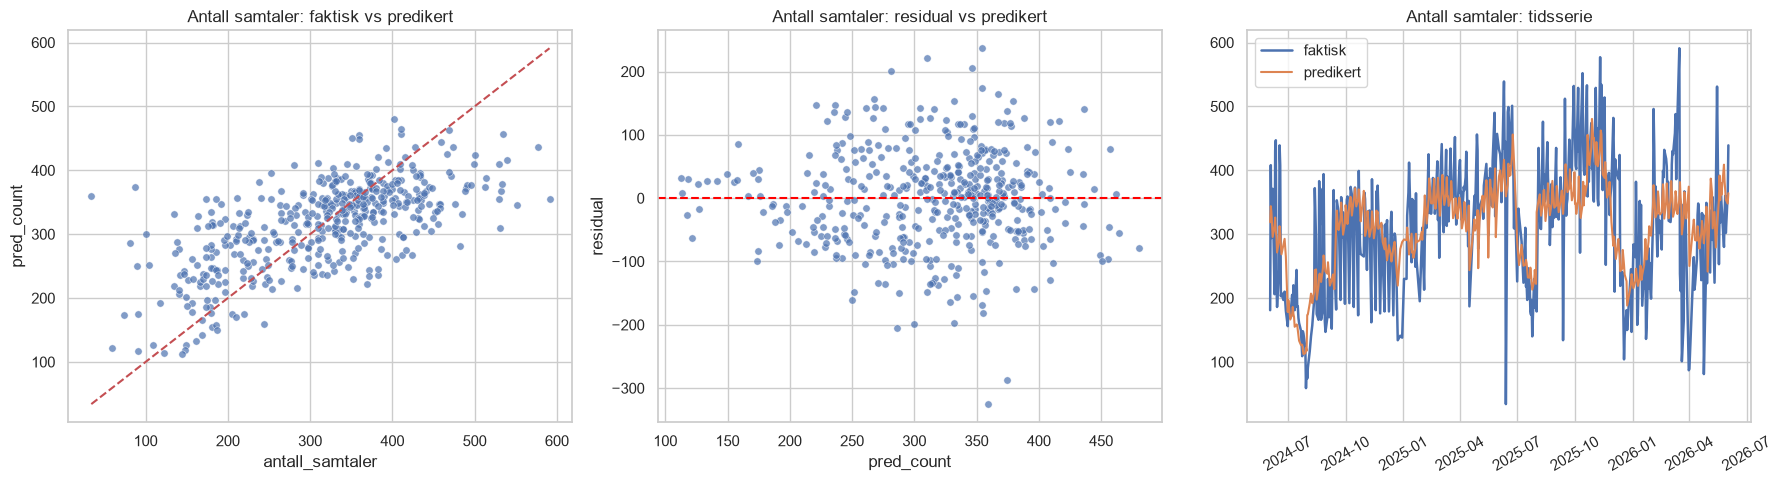

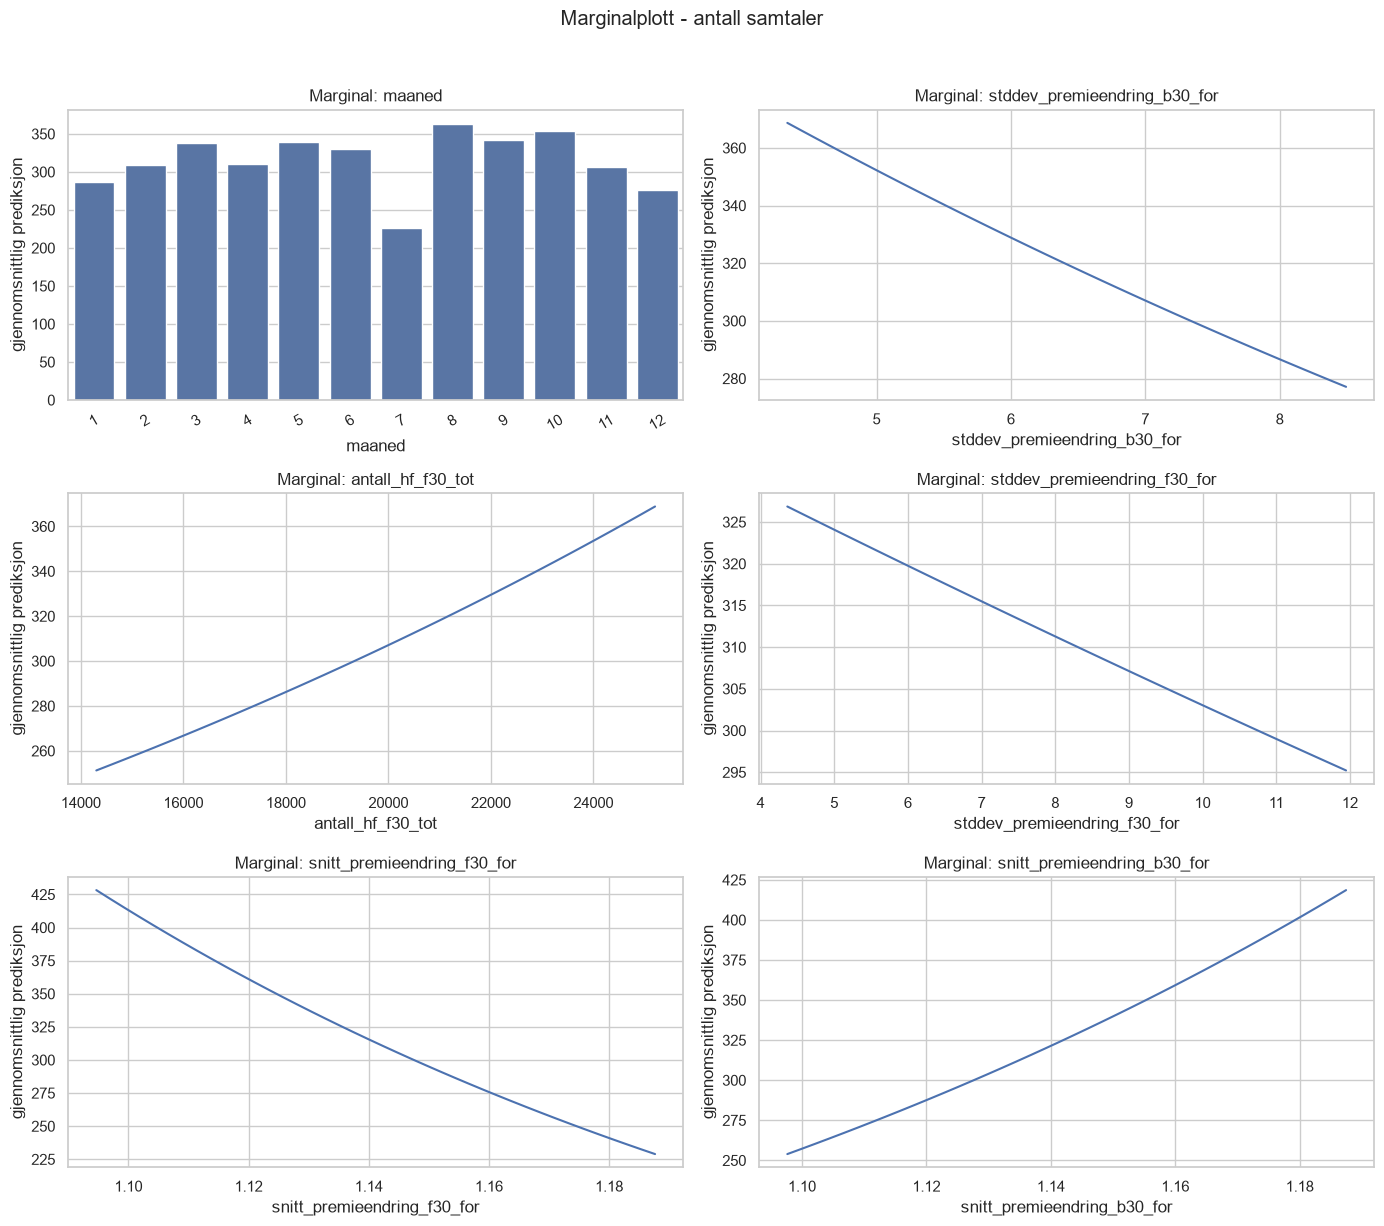

In [39]:
# Diagnostikk + marginalplott: antall samtaler
plot_diagnostics(
    df_plot=count_frame,
    y_col=COUNT_TARGET,
    pred_col="pred_count",
    date_col="ankomst_dato",
    title="Antall samtaler",
)

plot_marginal_effects(
    model=count_model,
    X_ref=count_frame[count_feature_cols],
    feature_cols=count_feature_cols,
    categorical_cols=cat_count,
    title="Marginalplott - antall samtaler",
    max_vars=min(6, len(count_feature_cols)),
)

In [40]:
# 2) Modell for snitt behandlingstid (Ridge, vektet med antall samtaler)
duration_cv_metrics = cross_validate_mean_duration_model(
    df=duration_frame,
    feature_cols=duration_feature_cols,
    target_col=DURATION_TARGET,
    categorical_features=cat_duration,
    k=K_FOLDS,
    random_state=RANDOM_STATE,
    sample_weight_col=WEIGHT_COL,
)

duration_model = fit_mean_duration_model(
    df=duration_frame,
    feature_cols=duration_feature_cols,
    target_col=DURATION_TARGET,
    categorical_features=cat_duration,
    sample_weight=duration_frame[WEIGHT_COL],
)

duration_frame = duration_frame.copy()
duration_frame["pred_duration"] = np.clip(duration_model.predict(duration_frame[duration_feature_cols]), 1e-9, None)

w_duration = duration_frame[WEIGHT_COL].astype(float).to_numpy()
duration_fit_metrics = {
    **metric_row(duration_frame[DURATION_TARGET], duration_frame["pred_duration"]),
    "mae_w": mean_absolute_error(duration_frame[DURATION_TARGET], duration_frame["pred_duration"], sample_weight=w_duration),
    "rmse_w": float(np.sqrt(mean_squared_error(duration_frame[DURATION_TARGET], duration_frame["pred_duration"], sample_weight=w_duration))),
    "r2_w": r2_score(duration_frame[DURATION_TARGET], duration_frame["pred_duration"], sample_weight=w_duration),
}

print("Duration CV (vektet):")
pd.Series(duration_cv_metrics)
print("\nDuration fit metrics:")
pd.Series(duration_fit_metrics)

Duration CV (vektet):

Duration fit metrics:


mae       23.249092
rmse      30.511543
r2         0.269744
mae_w     21.492531
rmse_w    28.027968
r2_w       0.280968
dtype: float64

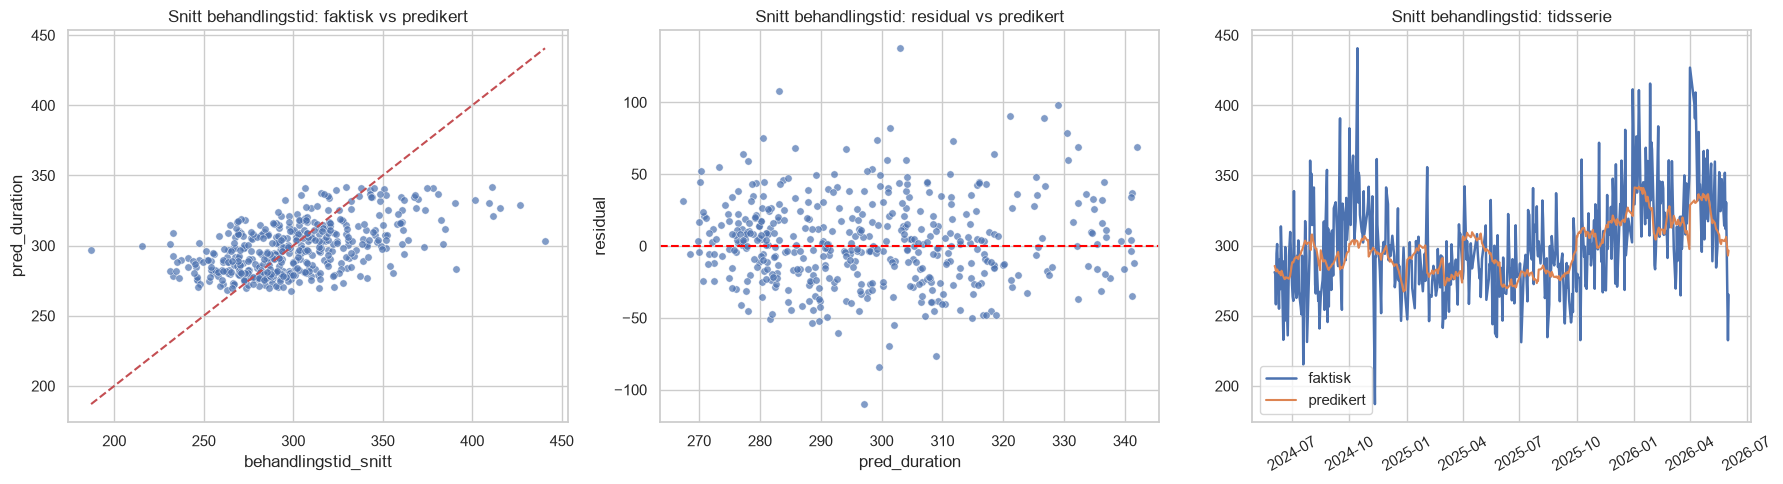

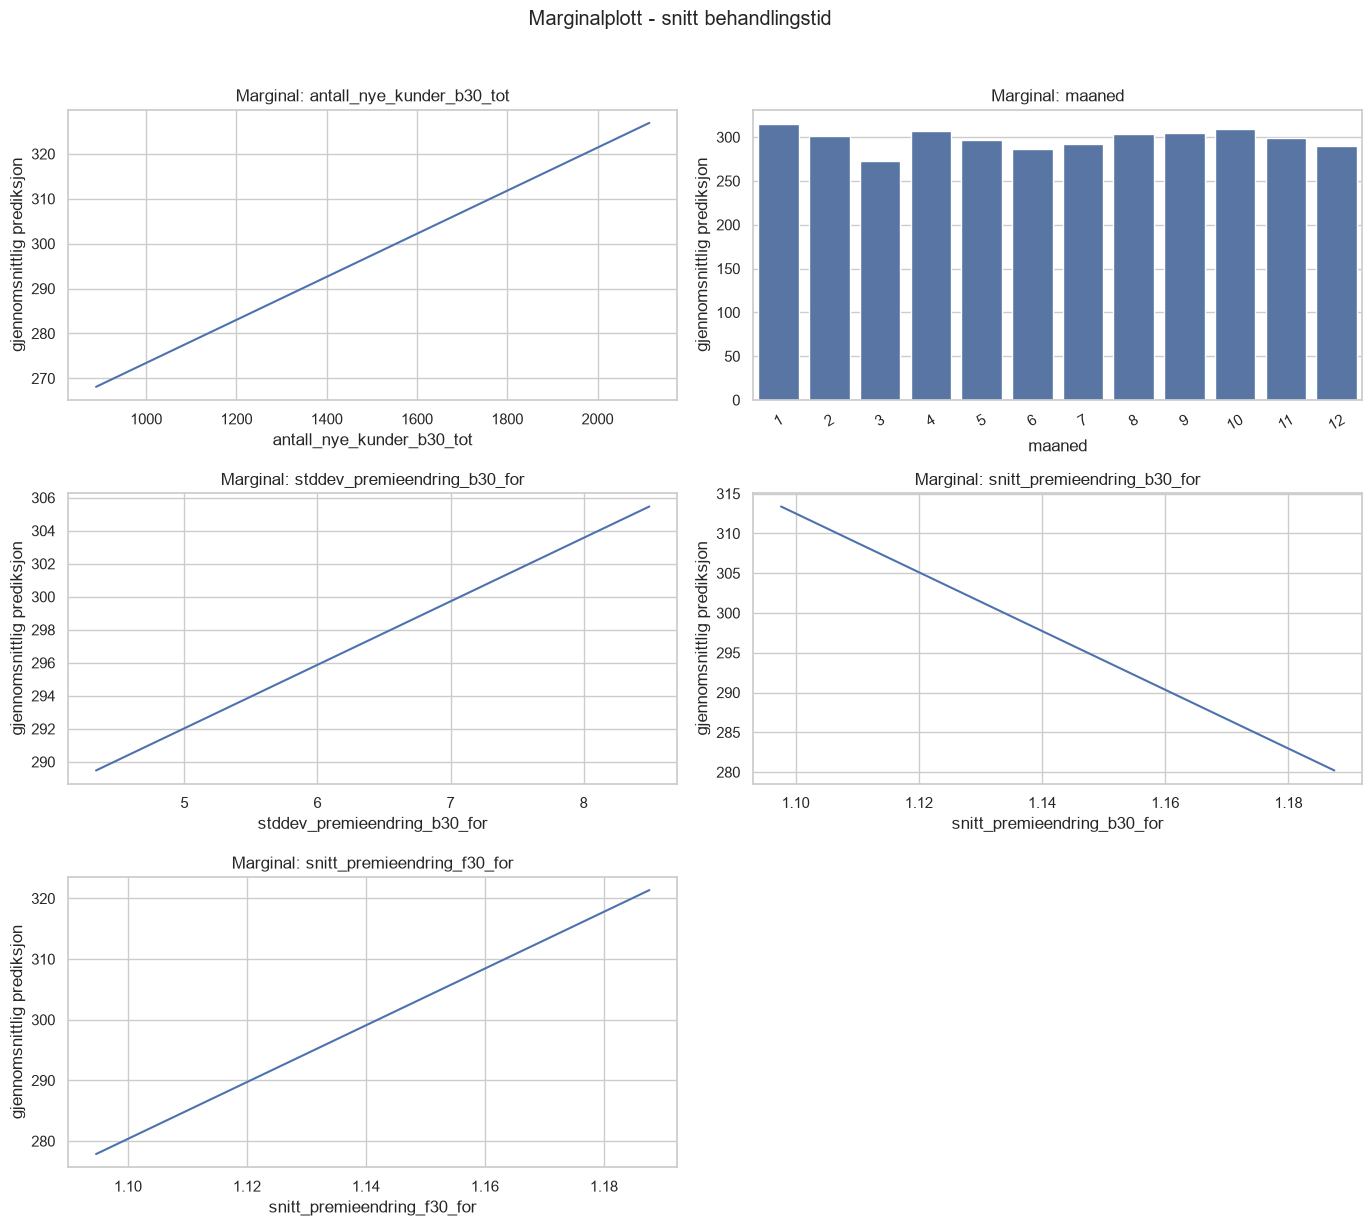

In [41]:
# Diagnostikk + marginalplott: snitt behandlingstid
plot_diagnostics(
    df_plot=duration_frame,
    y_col=DURATION_TARGET,
    pred_col="pred_duration",
    date_col="ankomst_dato",
    title="Snitt behandlingstid",
)

plot_marginal_effects(
    model=duration_model,
    X_ref=duration_frame[duration_feature_cols],
    feature_cols=duration_feature_cols,
    categorical_cols=cat_duration,
    title="Marginalplott - snitt behandlingstid",
    max_vars=min(6, len(duration_feature_cols)),
)

In [42]:
# 3) Endelig produktmodell: union av variabler fra count og duration
cv = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_rows = []
fold_rows = []

X_all = product_frame[product_feature_cols]
y_count_all = product_frame[COUNT_TARGET].astype(float)
y_duration_all = product_frame[DURATION_TARGET].astype(float)
y_total_all = product_frame[TOTAL_TARGET].astype(float)
w_all = product_frame[WEIGHT_COL].astype(float)

for fold, (train_idx, test_idx) in enumerate(cv.split(product_frame), start=1):
    X_train = X_all.iloc[train_idx]
    X_test = X_all.iloc[test_idx]

    y_count_train = y_count_all.iloc[train_idx]
    y_duration_train = y_duration_all.iloc[train_idx]
    y_total_test = y_total_all.iloc[test_idx]

    w_train = w_all.iloc[train_idx].to_numpy()
    w_test = w_all.iloc[test_idx].to_numpy()

    count_union_model = build_count_model(
        X_train,
        categorical_features=cat_product,
        alpha=POISSON_ALPHA,
        max_iter=POISSON_MAX_ITER,
    )
    count_union_model.fit(X_train, y_count_train)

    duration_union_model = build_mean_duration_model(
        X_train,
        categorical_features=cat_product,
        alpha=1.0,
    )
    duration_union_model.fit(X_train, y_duration_train, model__sample_weight=w_train)

    pred_count = np.clip(count_union_model.predict(X_test), 1e-9, None)
    pred_duration = np.clip(duration_union_model.predict(X_test), 1e-9, None)
    pred_total = pred_count * pred_duration

    m = metric_row(y_total_test, pred_total)
    m_w = metric_row(y_total_test, pred_total, sample_weight=w_test)

    fold_rows.append(
        {
            "fold": fold,
            "mae": m["mae"],
            "rmse": m["rmse"],
            "r2": m["r2"],
            "mae_w": m_w["mae"],
            "rmse_w": m_w["rmse"],
            "r2_w": m_w["r2"],
        }
    )

    fold_oof = product_frame.iloc[test_idx][["ankomst_dato", TOTAL_TARGET, WEIGHT_COL]].copy()
    fold_oof["pred_total"] = pred_total
    oof_rows.append(fold_oof)

product_cv_df = pd.DataFrame(fold_rows)
product_cv_summary = pd.Series(
    {
        "mae_mean": product_cv_df["mae"].mean(),
        "mae_std": product_cv_df["mae"].std(),
        "rmse_mean": product_cv_df["rmse"].mean(),
        "rmse_std": product_cv_df["rmse"].std(),
        "r2_mean": product_cv_df["r2"].mean(),
        "r2_std": product_cv_df["r2"].std(),
        "mae_w_mean": product_cv_df["mae_w"].mean(),
        "mae_w_std": product_cv_df["mae_w"].std(),
        "rmse_w_mean": product_cv_df["rmse_w"].mean(),
        "rmse_w_std": product_cv_df["rmse_w"].std(),
        "r2_w_mean": product_cv_df["r2_w"].mean(),
        "r2_w_std": product_cv_df["r2_w"].std(),
    }
)

print("Product CV (OOF, union-features):")
product_cv_summary

Product CV (OOF, union-features):


mae_mean       16923.813974
mae_std         1821.409480
rmse_mean      22444.291718
rmse_std        2249.989682
r2_mean            0.396498
r2_std             0.101159
mae_w_mean     16734.268058
mae_w_std       2017.334468
rmse_w_mean    21921.298824
rmse_w_std      2704.862735
r2_w_mean          0.294240
r2_w_std           0.144740
dtype: float64

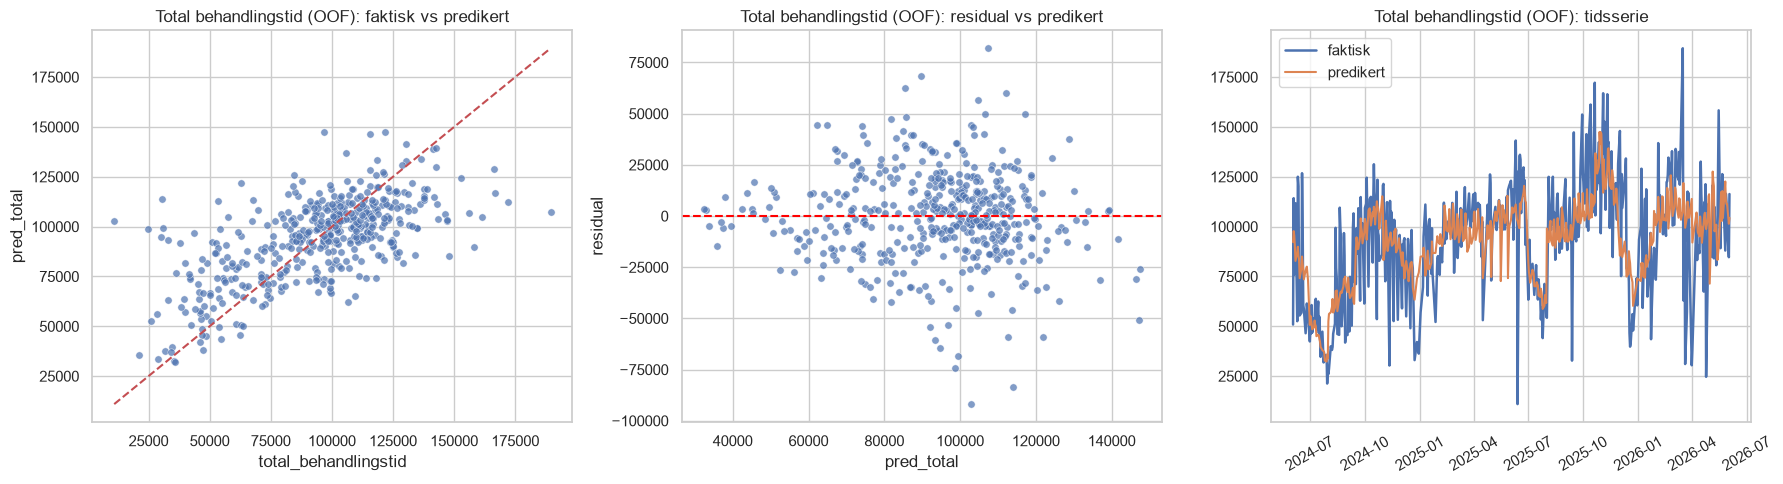

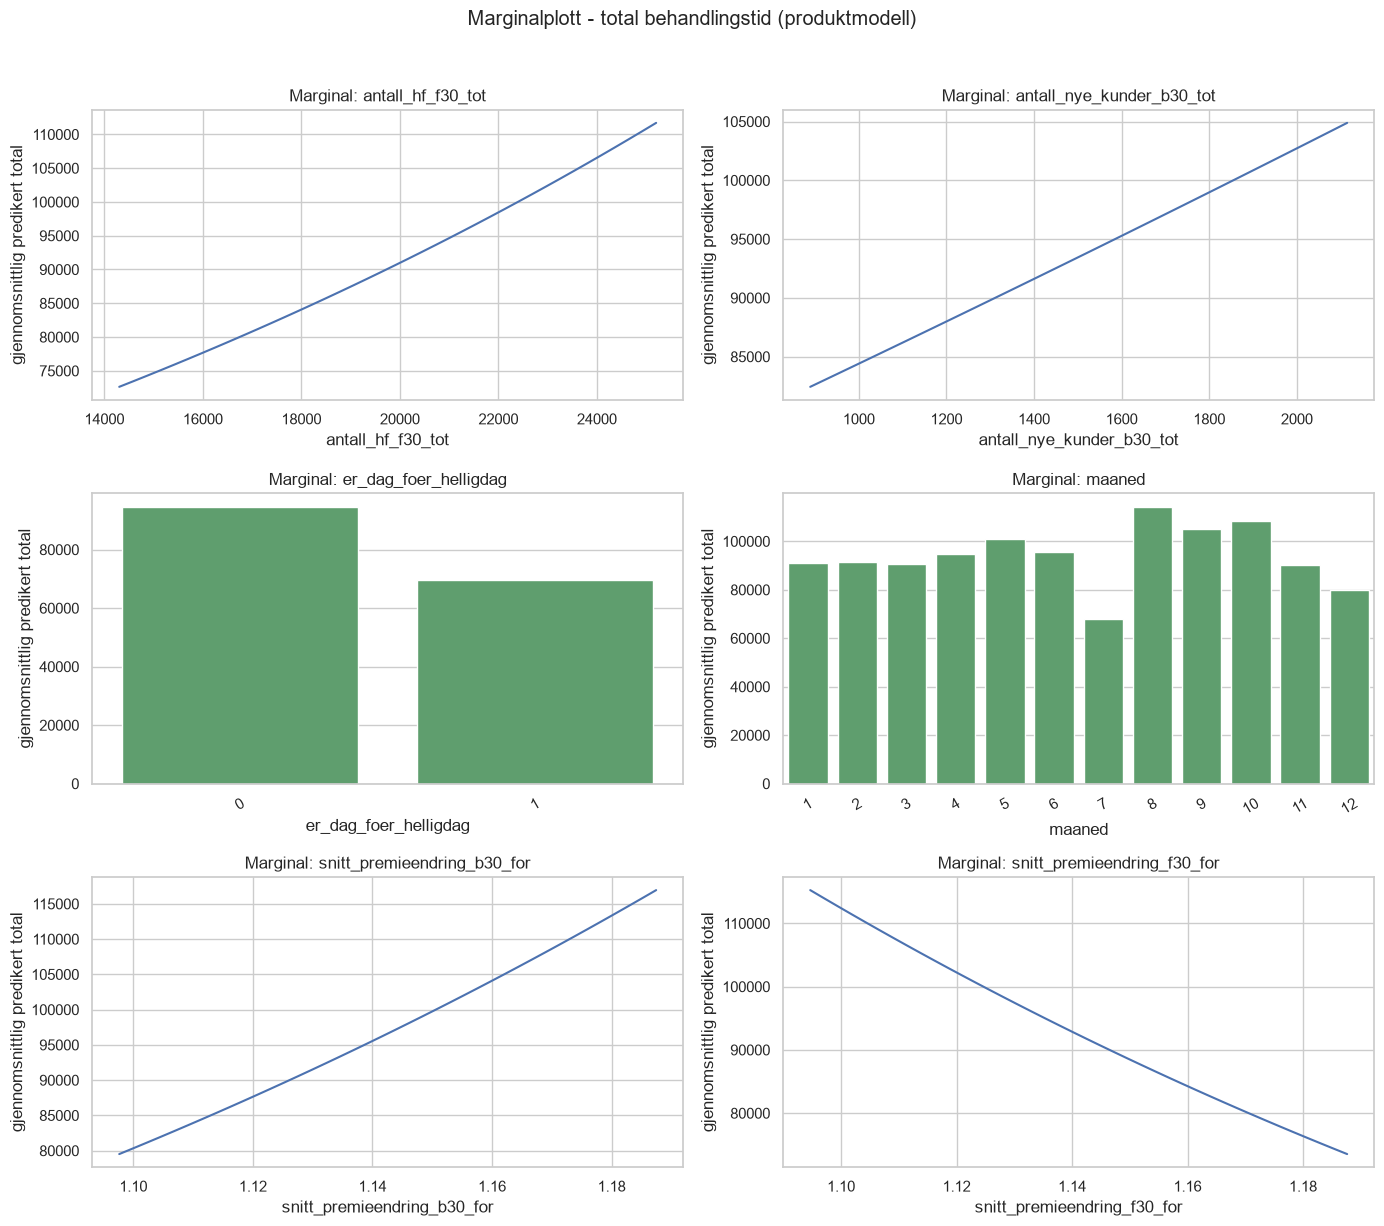

In [43]:
# Endelig fit på hele datasettet (union) + diagnostikk + marginalplott for produkt
oof_product_df = pd.concat(oof_rows, ignore_index=True).sort_values("ankomst_dato").reset_index(drop=True)
plot_diagnostics(
    df_plot=oof_product_df,
    y_col=TOTAL_TARGET,
    pred_col="pred_total",
    date_col="ankomst_dato",
    title="Total behandlingstid (OOF)",
)

count_union_final = build_count_model(
    X_all,
    categorical_features=cat_product,
    alpha=POISSON_ALPHA,
    max_iter=POISSON_MAX_ITER,
)
count_union_final.fit(X_all, y_count_all)

duration_union_final = build_mean_duration_model(
    X_all,
    categorical_features=cat_product,
    alpha=1.0,
)
duration_union_final.fit(X_all, y_duration_all, model__sample_weight=w_all.to_numpy())

plot_product_marginals(
    count_model=count_union_final,
    duration_model=duration_union_final,
    X_ref=X_all,
    feature_cols=product_feature_cols,
    categorical_cols=cat_product,
    title="Marginalplott - total behandlingstid (produktmodell)",
    max_vars=min(6, len(product_feature_cols)),
)